In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sorl.steer import StackedAbstractionWrapperV6, StackedAbstractionWrapperV9
from huggingface_hub import hf_hub_download, list_repo_files
import os, json, glob
from data.pt_dataset import ScienceQADataset
from sorl.analyze import load_steered_model, load_sft_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Config ----
# REPO = "Ksgk-fy/sciqa_ckpt_20260416_0942"
REPO = "Ksgk-fy/sciqa_ckpt_20260416_1452"
# RUN =  "q4b_sciqa_v6_C32_base" # -> use "v9" to tell apart from v6
RUN="l1_sciqa_v9_C32_detach_az0.5_aa0.5"
# RUN = "l3_sciqa_v6_C32_base"

sft_ckpt_name = RUN.split("_v")[0] + "_ep1"
sft_matches = glob.glob(f"ckpt/sft_sciqa_*/{sft_ckpt_name}/final.pt")
SFT_CKPT_PATH = sft_matches[0] if sft_matches else ""

# Load: sorl wrapper (LoRA adapter re-attached inside load_steered_model if args['use_lora'])
wrapper, tokenizer, args = load_steered_model(RUN, REPO, DEVICE)

# Load: plain base model + SFT model (LoRA auto-detected from ckpt['config'])
base_model = AutoModelForCausalLM.from_pretrained(args["model_name"]).to(DEVICE)
sft_model  = load_sft_model(SFT_CKPT_PATH, args["model_name"], DEVICE)

# Load: latent codes data for the sorl wrapper model
code_pt_file = (glob.glob(f"*/analysis_out/decode_scale_*/{RUN}_*ps{args['scale']}*_respprompt.pt")
                + glob.glob(f"analysis_out/decode_scale_*/{RUN}_*ps{args['scale']}*_respprompt.pt"))[0]
blob = torch.load(code_pt_file, map_location="cpu", weights_only=False)
samples = blob["samples"]
codes   = blob["codes"]
L       = blob["L"]
C_SIZE  = blob["C_SIZE"]

val_ds = ScienceQADataset(split="test", tokenizer=tokenizer, max_length=512)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Mode: v9, Model: meta-llama/Llama-3.2-1B
C=32, L=4, scale=0.1, layers=10
Loaded l1_sciqa_v9_C32_detach_az0.5_aa0.5 -> StackedAbstractionWrapperV9 on cpu
  steering_emb: (32, 2048)
  abs_proj: (32, 2048)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

No SFT ckpt at ''; skipping.


In [3]:
from sorl.analyze import steering_vector_cosine, steering_magnitude_report

# (I). Avg cosine similarity between different steering vectors
avg_cos, cos_sim = steering_vector_cosine(wrapper)

# (II). Confirm the relative mag
# nitude of steering vectors (scaled) to the non-steered representation
stats = steering_magnitude_report(wrapper, val_ds, device=DEVICE, n_ex=32, skip=4)

Avg pairwise cosine similarity: 0.0116


KeyboardInterrupt: 

#### N-Gram Specialization

src='response'  topics kept (>= 5 seqs): 19 / 25
run=l1_sciqa_v9_C32_detach_az0.5_aa0.5  prompt_scale=0.1  acc=52.80%
sequences kept: 1984
inner-monologue length:  mean=63.8  median=64  min=63  max=64  p5/p95=(63,64)
null-baseline purity = max topic share = 17.4%  (argmax topic: biology, n=345)

  1-grams  |  per-topic top-8 by PMI  (min count in topic = 5)

  [biology]  (345 seqs, 21990 1-grams)
    gram                        in_topic  global  in/gl%    PMI    lift
    (23,)                            413    1227   33.7%  +0.66   1.94x
    (5,)                            1624    5568   29.2%  +0.52   1.68x
    (14,)                            480    2125   22.6%  +0.26   1.30x
    (20,)                            386    1769   21.8%  +0.23   1.26x
    (21,)                            300    1398   21.5%  +0.21   1.23x
    (2,)                            2089   10181   20.5%  +0.17   1.18x
    (16,)                            353    1768   20.0%  +0.14   1.15x
    (10,)               

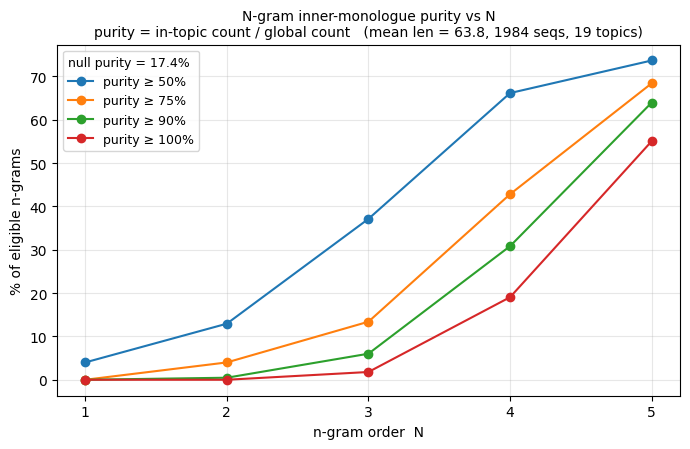

In [ ]:
# Which codes / bigrams / trigrams / ... are specific to each topic?
#
#   purity(g) = in_topic_count(g) / global_count(g)
#
# `purity_sweep_report` prints per-topic top-K PMI grams, the purity
# threshold sweep, plots % eligible vs N, and harvests topic-specialized
# n-grams + their participating codes for the causal ablation below.
from sorl.analyze import purity_sweep_report

report = purity_sweep_report(
    blob["samples"], blob["codes"], val_ds,
    src="response",
    n_grams=(1, 2, 3, 4, 5),
    top_k=8,
    min_topic_seqs=5,
    min_gram_count_in_topic=5,
    min_gram_count_global=30,
    purity_thresholds=(0.50, 0.75, 0.90, 1.00),
    harvest_purity=0.90,
    harvest_min_count=10,
    harvest_N=(1, 2, 3),
    run_label=blob["run"], accuracy=blob["accuracy"],
)
topic_codes  = report["topic_codes"]
topic_ngrams = report["topic_ngrams"]


In [ ]:
# StoryLine: 
# [obs 1] Sorl has bigger effective rank in its representation compared to SFT
# [obs 2] Sorl has specialized n-gram for each topic 
# [Argument a] Sorl uses dynamic steering for different type of sequences, it learns structured inner-monologue that aligned with the data. 
# [obs 3] When specialized n-gram are ablated, the corresponding topic has heavy drop in accuracy
# [Argument b] Sorl's topic specific steering is necessary for its performance
# Combining argument a & b, we know sorl uses dynamics steering for different sequences, this is 
# important for its accuracy

#### Causal Effect of N-Gram

In [ ]:
# [obs 3] Causal ablation of topic-specialized codes.
#
# For each topic t, ablate every code that participates in t's
# topic-specialized n-grams (harvested in the purity cell), then re-evaluate
# the full SciQA val set. Expectation:
#   - diagonal drops (topic t accuracy falls when t's codes are ablated)
#   - off-diagonal roughly stable
# Plus a same-size random-code control. Cached per-(label, n) to disk so
# interrupted runs resume cleanly.
from sorl.analyze import run_topic_ablation_eval

assert "topic_codes" in globals(), "Run the purity cell first."

ablation = run_topic_ablation_eval(
    wrapper, val_ds, tokenizer, samples, topic_codes,
    device=DEVICE,
    run_name=blob["run"],
    c_size=C_SIZE,
    max_new_tokens=128,
    eval_n=None,          # full val set; set to a small int for debugging
    n_random_ctrl=2,
    ctrl_seed=0,
)


AssertionError: Run the purity cell first to harvest topic_codes / topic_ngrams.

#### Effective Rank of Representation: SoRL > SFT

In [ ]:
# Build REPS: final-layer last-prompt-token hidden states for
# { base, sft, steered } on the same eval inputs. Consumed by the
# effective-rank / linear-probe cells below.
from sorl.analyze import build_reps

REPS, topics, keep = build_reps(
    {"base": base_model, "sft": sft_model, "steered": wrapper},
    val_ds, DEVICE,
    n_eval=40,
    batch_size=4,
    layer_idx=-1,
    min_size_topic=20,
    cast_to_dtype=next(wrapper.parameters()).dtype,
)

Eval: 40 / 2224 samples


NameError: name 'sft_model' is not defined

In [ ]:
from sorl.analyze import effective_rank_report

assert "REPS" in globals(), "Run the build_reps cell first."
erank = effective_rank_report(REPS, names=("base", "sft", "steered"))
